In [1]:
import numpy as np
import pandas as pd
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt

In [2]:
# load data
data = pd.read_csv("../data/full_data.csv")
data.head()

C:\Users\miale.a\AppData\Local\Temp\ipykernel_13152\3577333053.py:2: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/full_data.csv")


,Unnamed: 0,player_id_event,match_id,frame_start,frame_end,event_id,event_type,team_id_event,player_in_possession_id,x_start,...,number,team_id_tracking,team_name,player_role.position_group,total_time,player_role.name,player_role.acronym,is_gk,direction_player_1st_half,direction_player_2nd_half
0,0,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,1,1805,Newcastle United Jets FC,Other,5400,Goalkeeper,GK,True,left_to_right,right_to_left
1,1,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,4,1805,Newcastle United Jets FC,Central Defender,5400,Right Center Back,RCB,False,left_to_right,right_to_left
2,2,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,15,1805,Newcastle United Jets FC,Central Defender,5400,Left Center Back,LCB,False,left_to_right,right_to_left
3,3,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,14,1805,Newcastle United Jets FC,Full Back,5400,Right Back,RB,False,left_to_right,right_to_left
4,4,966120,1886347,28,28,8_0,player_possession,1805,NaN,0.73,...,33,1805,Newcastle United Jets FC,Full Back,5400,Left Back,LB,False,left_to_right,right_to_left


In [3]:
print(data.columns.tolist())

['Unnamed: 0', 'player_id_event', 'match_id', 'frame_start', 'frame_end', 'event_id', 'event_type', 'team_id_event', 'player_in_possession_id', 'x_start', 'y_start', 'x_end', 'y_end', 'x', 'y', 'player_id_tracking', 'is_detected', 'frame', 'timestamp', 'period', 'possession_player_id', 'possession_group', 'ball_x', 'ball_y', 'ball_z', 'is_detected_ball', 'start_time', 'end_time', 'match_name', 'date_time', 'home_team.name', 'away_team.name', 'id', 'short_name', 'number', 'team_id_tracking', 'team_name', 'player_role.position_group', 'total_time', 'player_role.name', 'player_role.acronym', 'is_gk', 'direction_player_1st_half', 'direction_player_2nd_half']


In [4]:
print(data["frame_start"].value_counts())

frame_start
10770    264
5804     264
11649    264
44221    264
3890     242
        ... 
47543     22
45439     22
69737     22
69743     22
69747     22
Name: count, Length: 24929, dtype: int64


In [5]:
# get some columns
print(data[data["frame_start"]==28][["x", "y", "ball_x", "ball_y", "number", "team_id_tracking", "frame", "timestamp"]])
test = data[data["frame_start"]==28][["x", "y", "ball_x", "ball_y", "number", "team_id_tracking", "frame", "timestamp"]]

        x      y  ball_x  ball_y  number  team_id_tracking  frame  \
0  -40.71  -0.27    0.03   -0.36       1              1805     28   
1  -19.33  -9.63    0.03   -0.36       4              1805     28   
2  -21.72   0.22    0.03   -0.36      15              1805     28   
3   -0.64 -33.03    0.03   -0.36      14              1805     28   
4  -20.11  15.75    0.03   -0.36      33              1805     28   
5   -6.52   6.95    0.03   -0.36      19              1805     28   
6   -9.58  -5.04    0.03   -0.36      17              1805     28   
7   -0.15   8.15    0.03   -0.36      37              1805     28   
8   -1.09 -20.49    0.03   -0.36       7              1805     28   
9   -1.08  18.69    0.03   -0.36      39              1805     28   
10   0.73   0.49    0.03   -0.36      22              1805     28   
11  41.94   0.14    0.03   -0.36      12              4177     28   
12  17.93   4.82    0.03   -0.36      23              4177     28   
13  17.43  -3.57    0.03   -0.36  

In [6]:
# convert teams to 0/1
test["team_id_tracking"] = list(map(lambda test: 1 if test==1805 else 0, test["team_id_tracking"]))
print(test["team_id_tracking"])

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
Name: team_id_tracking, dtype: int64


In [7]:
# get x and y for each team
x1 = test[test["team_id_tracking"]==1]["x"]
y1 = test[test["team_id_tracking"]==1]["y"]
x2 = test[test["team_id_tracking"]!=1]["x"]
y2 = test[test["team_id_tracking"]!=1]["y"]

In [8]:
# get individual list of each column
x = test["x"].tolist()
y = test["y"].tolist()
ball_x = test["ball_x"].iloc[0]
ball_y = test["ball_y"].iloc[0]
numbers = test["number"].tolist()
team_id = test["team_id_tracking"].tolist()

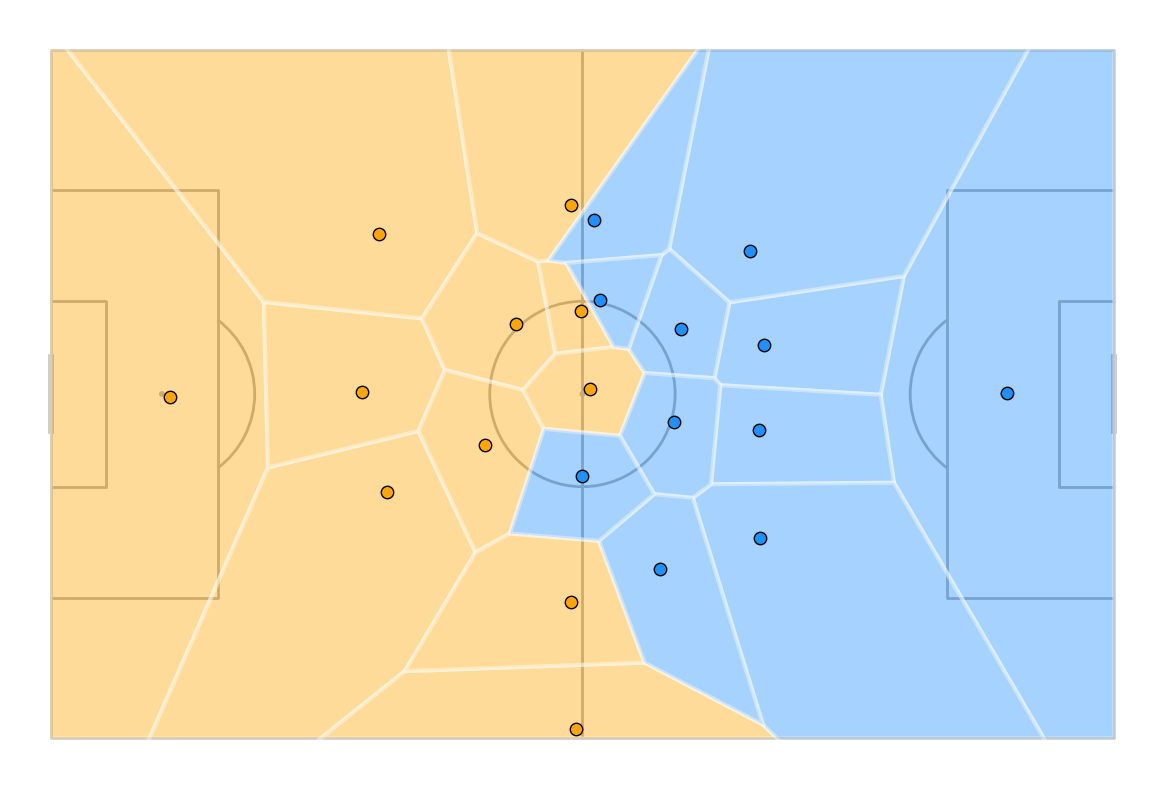

In [9]:
# plot voronoi of snapshot
p = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68)
fig, ax = p.draw(figsize=(12,8))

# Plot Voronoi
team1, team2 = p.voronoi(x, y, team_id)
t1 = p.polygon(team1, ax=ax, fc='orange', ec='white', lw=3, alpha=0.4)
t2 = p.polygon(team2, ax=ax, fc='dodgerblue', ec='white', lw=3, alpha=0.4)

# Plot players
sc1 = p.scatter(x1, y1, c='orange', s=80, ec='k', ax=ax)
sc2 = p.scatter(x2, y2, c='dodgerblue', s=80, ec='k', ax=ax)